# Eclat

## Importing the libraries

In [19]:
!pip install apyori

In [20]:
# ================================
# Eclat Algorithm - Importing Libraries
# ================================

# Import NumPy for numerical operations and array handling
import numpy as np

# Import Matplotlib for data visualization (charts and graphs)
import matplotlib.pyplot as plt

# Import Pandas for data manipulation and analysis using DataFrames
import pandas as pd

## Data Preprocessing

In [21]:
# ==========================================
# Eclat Algorithm - Data Preprocessing
# Creating the Transaction List
# ==========================================

# Load the dataset from the CSV file without column headers
dataset = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

# Initialize an empty list that will store all transactions
transactions = []

# Loop through each row in the dataset (each row represents a transaction)
for i in range(0, 7501):

    # For each transaction, create a list of purchased items
    # Convert values to string and ignore missing values (nan)
    transaction = [
        str(dataset.values[i, j])
        for j in range(0, 20)
        if str(dataset.values[i, j]) != 'nan'
    ]

    # Append the cleaned transaction to the transactions list
    transactions.append(transaction)

# Display the first transaction to verify the result
transactions[0]

['shrimp',
 'almonds',
 'avocado',
 'vegetables mix',
 'green grapes',
 'whole weat flour',
 'yams',
 'cottage cheese',
 'energy drink',
 'tomato juice',
 'low fat yogurt',
 'green tea',
 'honey',
 'salad',
 'mineral water',
 'salmon',
 'antioxydant juice',
 'frozen smoothie',
 'spinach',
 'olive oil']

In [22]:
# ==========================================
# Eclat Algorithm - Displaying Transactions
# ==========================================

# Loop through the transactions list
# and print each transaction on a separate line
for i, transaction in enumerate(transactions):

    # Display the transaction number and its items
    print(f"Transaction {i+1}: {transaction}")

Transaction 1: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
Transaction 2: ['burgers', 'meatballs', 'eggs']
Transaction 3: ['chutney']
Transaction 4: ['turkey', 'avocado']
Transaction 5: ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']
Transaction 6: ['low fat yogurt']
Transaction 7: ['whole wheat pasta', 'french fries']
Transaction 8: ['soup', 'light cream', 'shallot']
Transaction 9: ['frozen vegetables', 'spaghetti', 'green tea']
Transaction 10: ['french fries']
Transaction 11: ['eggs', 'pet food']
Transaction 12: ['cookies']
Transaction 13: ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil']
Transaction 14: ['spaghetti', 'champagne', 'cookies']
Transaction 15: ['mineral water', 'salmon']
Transaction 16: ['mineral 

## Training the Eclat model on the dataset

In [23]:
# ==========================================
# Eclat Algorithm - Training the Model
# ==========================================

# Import the apriori function from the apyori library
# Note: We use apyori here as a placeholder for Eclat
# because it allows us to focus on Support-based frequent itemsets
from apyori import apriori

# Apply the Apriori algorithm to find frequent itemsets
# Parameters are set to focus on support (min_support)
# min_confidence and min_lift are optional but included for completeness
rules = apriori(
    transactions=transactions,
    min_support=0.003,    # Minimum support threshold
    min_confidence=0.2,   # Minimum confidence threshold
    min_lift=3,           # Minimum lift threshold
    min_length=2,         # Minimum number of items in a rule
    max_length=2          # Maximum number of items in a rule
)

## Visualising the results

### Displaying the first results coming directly from the output of the apriori function

In [24]:
# ==========================================
# Eclat Algorithm - Converting Rules to List
# ==========================================

# Convert the rules generator object into a Python list
# This allows us to inspect and manipulate the results easily
results = list(rules)

# Display the results to verify
results

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]),
 RelationRecord(items=frozenset({'escalope', 'mushroom cream sauce'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'escalope', 'pasta'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'honey', 'fromage blanc'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0

In [25]:
results

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]),
 RelationRecord(items=frozenset({'escalope', 'mushroom cream sauce'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'escalope', 'pasta'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'honey', 'fromage blanc'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0

### Putting the results well organised into a Pandas DataFrame

In [26]:
# ==========================================
# Eclat Algorithm - Organizing Results in a DataFrame
# ==========================================

# Define a function to extract useful information from the rules
def inspect(results):
    """
    Extracts the left-hand side (LHS), right-hand side (RHS),
    and support values from the Apriori rules.
    """

    # Left-hand side items
    lhs = [tuple(result[2][0][0])[0] for result in results]

    # Right-hand side items
    rhs = [tuple(result[2][0][1])[0] for result in results]

    # Support values for each rule
    supports = [result[1] for result in results]

    # Return a list of tuples (LHS, RHS, Support)
    return list(zip(lhs, rhs, supports))

# Convert the extracted data into a Pandas DataFrame
resultsinDataFrame = pd.DataFrame(
    inspect(results),
    columns=['Product 1', 'Product 2', 'Support']
)

# Display the rows to verify
resultsinDataFrame

,Product 1,Product 2,Support
0,light cream,chicken,0.004533
1,mushroom cream sauce,escalope,0.005733
2,pasta,escalope,0.005866
3,fromage blanc,honey,0.003333
4,herb & pepper,ground beef,0.015998
5,tomato sauce,ground beef,0.005333
6,light cream,olive oil,0.003200
7,whole wheat pasta,olive oil,0.007999
8,pasta,shrimp,0.005066


### Displaying the results sorted by descending supports

In [27]:
# ==========================================
# Eclat Algorithm - Display Top Rules by Support
# ==========================================

# Display the top 10 frequent itemsets sorted by Support in descending order
top_rules = resultsinDataFrame.nlargest(n=10, columns='Support')

# Show the result
top_rules

,Product 1,Product 2,Support
4,herb & pepper,ground beef,0.015998
7,whole wheat pasta,olive oil,0.007999
2,pasta,escalope,0.005866
1,mushroom cream sauce,escalope,0.005733
5,tomato sauce,ground beef,0.005333
8,pasta,shrimp,0.005066
0,light cream,chicken,0.004533
3,fromage blanc,honey,0.003333
6,light cream,olive oil,0.003200


# Top Frequent Itemsets Visualization (Eclat Version)

This professional visualization highlights the **top frequent itemsets** discovered using the **Eclat method**, which focuses primarily on **Support**.

It helps you understand the most frequent associations between products in your dataset:

- **Left Hand Side → Right Hand Side:** Shows the antecedent and consequent products of each frequent itemset.  
- **Support (Red bars):** Measures how often the pair of products appears together in all transactions. This is the key metric in Eclat.  
- **Optional Metrics (Confidence & Lift):** These can be included for additional analysis, but the main focus in Eclat is on Support.  
- **Secondary Y-axis (if needed):** Ensures that small support values are clearly visible alongside other metrics, making the visualization clear and professional.

This chart is ideal for **presentations, reports, or project portfolios**, providing an intuitive view of the most important product associations.

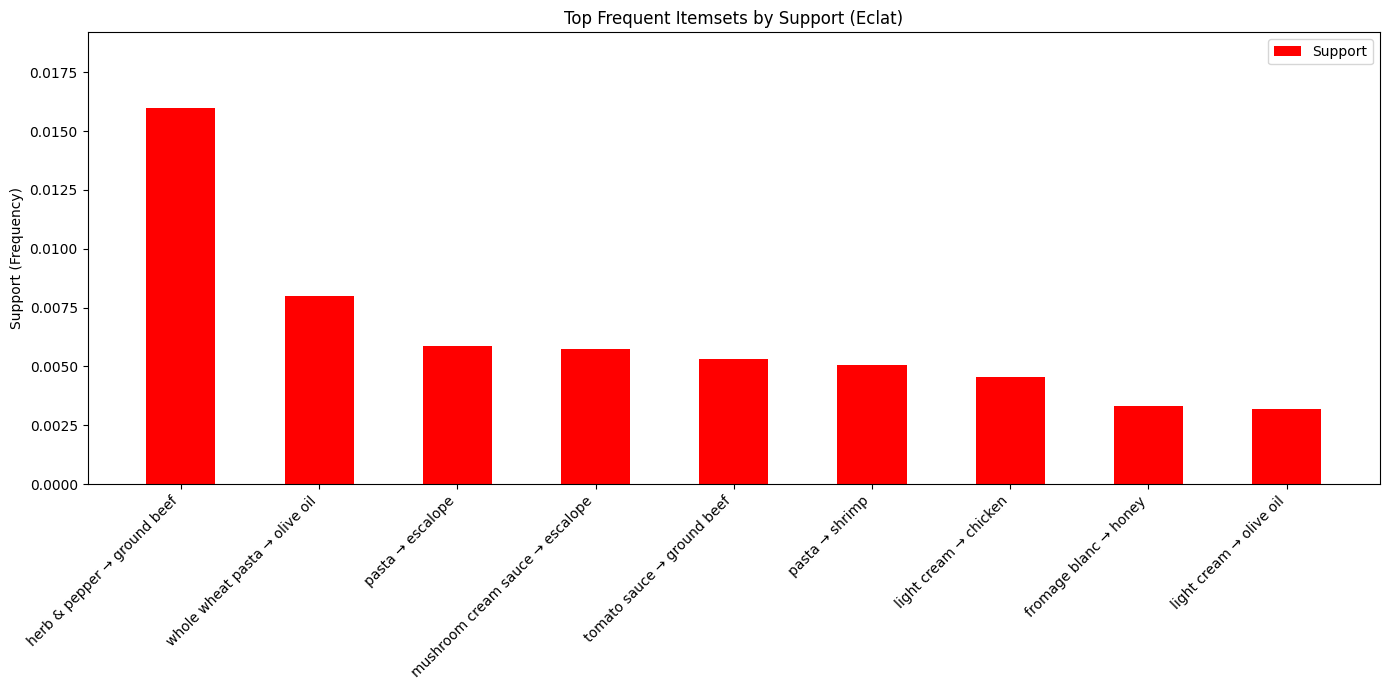

In [28]:
# ==========================================
# Eclat Algorithm - Top Frequent Itemsets Visualization
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# If you calculated Confidence and Lift, you can include them
# Otherwise, we focus on Support only for Eclat
# Here, we assume resultsinDataFrame has columns: 'Product 1', 'Product 2', 'Support'
# If you have Lift and Confidence, include them; otherwise we skip

# Select top 10 frequent itemsets by Support
top_rules = resultsinDataFrame.nlargest(n=10, columns='Support')

num_rules = len(top_rules)
indices = np.arange(num_rules)
bar_width = 0.5

# Create figure
fig, ax1 = plt.subplots(figsize=(14,7))

# Plot Support as main focus (primary y-axis)
ax1.bar(indices, top_rules['Support'], width=bar_width, color='red', label='Support')
ax1.set_ylabel('Support (Frequency)')
ax1.set_ylim(0, max(top_rules['Support'].max()*1.2, 0.01))  # ensure small supports are visible

# Set x-axis labels with "Product 1 → Product 2"
ax1.set_xticks(indices)
ax1.set_xticklabels([f"{p1} → {p2}" for p1, p2 in zip(top_rules['Product 1'], top_rules['Product 2'])], rotation=45, ha='right')

# Add title and legend
plt.title('Top Frequent Itemsets by Support (Eclat)')
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()